# Nuclear Waste Canister Temperature Prediction
**CIVIL-226 - Introduction to Machine Learning for Engineers**




**Members:** Nour NAJA |Alessandro CLERICI

## Objectif
Prédire la température autour de conteneurs de déchets nucléaires à des positions de capteurs non observés, en utilisant la puissance de chauffage, le temps, et les coordonnées spatiales des capteurs.

## 1. Imports

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)
print('Imports OK')

Imports OK


## 2. Chargement des données

In [3]:
sensors = pd.read_parquet('data/sensors.parquet')
train   = pd.read_parquet('data/train.parquet')
test    = pd.read_parquet('data/test.parquet')

# Suppression des capteurs dupliqués (N206 et N213 — coordonnées identiques, erreur de reporting)
n_before = len(sensors)
sensors = sensors.drop_duplicates(subset='sensor', keep='first').reset_index(drop=True)
print(f'Doublons supprimés : {n_before - len(sensors)} (N206, N213)')

print(f'Sensors : {sensors.shape}  ->  {sensors.columns.tolist()}')
print(f'Train   : {train.shape}   ->  {train.columns.tolist()}')
print(f'Test    : {test.shape}    ->  {test.columns.tolist()}')

Doublons supprimés : 2 (N206, N213)
Sensors : (323, 4)  ->  ['sensor', 'coor_x', 'coor_y', 'coor_z']
Train   : (6626928, 4)   ->  ['sensor', 'time', 'power', 'temperature']
Test    : (2190480, 3)    ->  ['sensor', 'time', 'power']


## 3. Data exploration 1

In [4]:
print('=== SENSORS ===')
display(sensors.head())
print(f'\n{sensors["sensor"].nunique()} capteurs uniques')

print('\n=== TRAIN ===')
display(train.head())
print(f'\nValeurs manquantes :')
print(train.isnull().sum())

=== SENSORS ===


,sensor,coor_x,coor_y,coor_z
0,N2,0.5,0.0,0.0
1,N4,1.4,0.0,0.0
2,N5,0.5,2.4,0.0
3,N6,0.0,2.4,0.0
4,N7,0.0,3.5,0.0



323 capteurs uniques

=== TRAIN ===


,sensor,time,power,temperature
0,N102,0.0,1487.964722,17.514429
1,N102,864000.0,1487.288818,17.820795
2,N102,1728000.0,1486.612915,17.573187
3,N102,2592000.0,1485.936890,16.513235
4,N102,3456000.0,1485.260986,16.303427



Valeurs manquantes :
sensor             0
time               0
power              0
temperature    99403
dtype: int64


## Merge sensors positions intro train data

In [5]:
train_full = train.merge(sensors, on="sensor", how="left")
print(train_full.head())
print(train_full.shape)

  sensor       time        power  temperature     coor_x  coor_y  coor_z
0   N102        0.0  1487.964722    17.514429  46.131474     3.5     0.0
1   N102   864000.0  1487.288818    17.820795  46.131474     3.5     0.0
2   N102  1728000.0  1486.612915    17.573187  46.131474     3.5     0.0
3   N102  2592000.0  1485.936890    16.513235  46.131474     3.5     0.0
4   N102  3456000.0  1485.260986    16.303427  46.131474     3.5     0.0
(6626928, 7)


## Clean Missing Values

In [6]:
train_full = train_full.dropna()
print(train_full.shape)
print(train_full.columns)

(6527525, 7)
Index(['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z'], dtype='str')


## 3. Data exploration 2

Temperature min: -292.15085
Temperature max: 6039.05

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


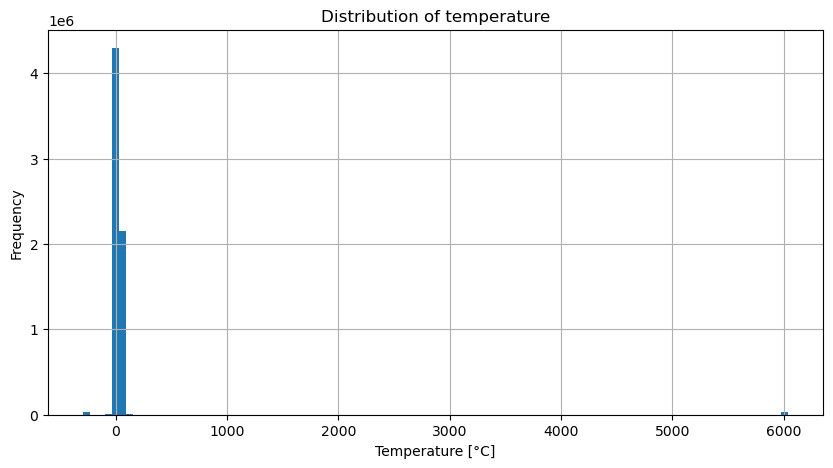

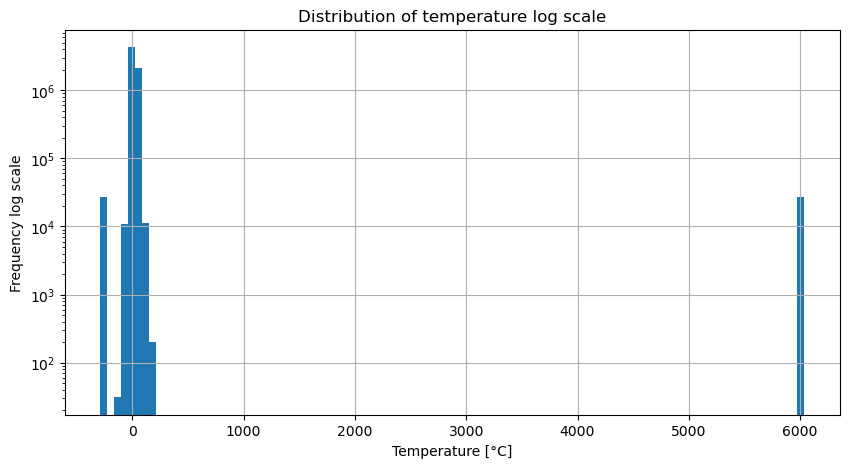

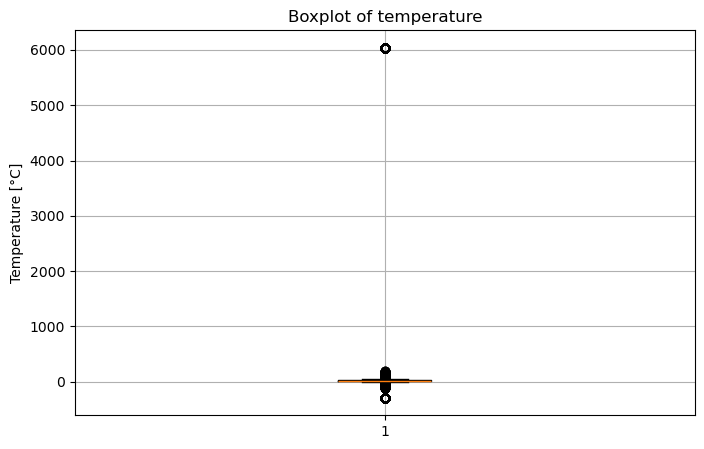

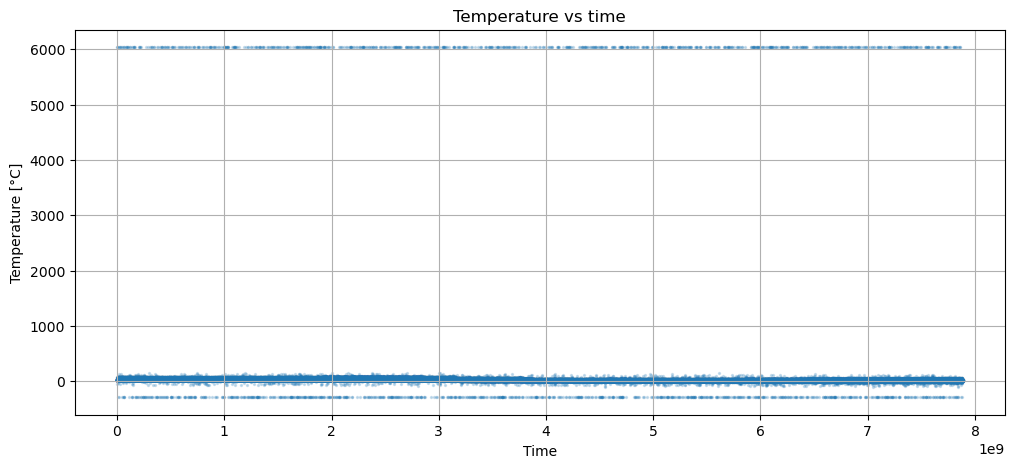

In [7]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

# Histogram (frequency_temperature)
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()

# Histogram (log frequency_temperature)
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()

# Box plot
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()

# Temperature_Time
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

In [8]:
import plotly.graph_objects as go
train_sensors = set(train['sensor'].unique())
test_sensors  = set(test['sensor'].unique())
s_train = sensors[sensors['sensor'].isin(train_sensors)]
s_test  = sensors[sensors['sensor'].isin(test_sensors)]

fig = go.Figure()
fig.add_trace(go.Scatter(x=s_train['coor_x'], y=s_train['coor_y'],
    mode='markers', name='Train sensors',
    marker=dict(size=6, color='steelblue', opacity=0.6)))
fig.add_trace(go.Scatter(x=s_test['coor_x'], y=s_test['coor_y'],
    mode='markers', name='Test sensors',
    marker=dict(size=8, color='tomato', symbol='diamond', opacity=0.9)))
fig.update_layout(title='Positions des capteurs (2D)',
    xaxis_title='X', yaxis_title='Y', width=700, height=500)
fig.show()

print(f'Capteurs train dans buffer (x<=1.4) : {(s_train["coor_x"] <= 1.4).sum()}')
print(f'Capteurs test dans buffer (x<=1.4)  : {(s_test["coor_x"] <= 1.4).sum()}')

Capteurs train dans buffer (x<=1.4) : 56
Capteurs test dans buffer (x<=1.4)  : 18


## 4. Preprocessing 

### MAD : remove outliers

In [9]:
# ============================================================
# Identify global temperature outliers using MAD
# ============================================================

temp = train_full["temperature"]

median_temp = temp.median()
mad_temp = np.median(np.abs(temp - median_temp))

robust_z = 0.6745 * (temp - median_temp) / (mad_temp + 1e-8)

train_full["temperature_robust_z"] = robust_z
train_full["is_global_outlier"] = train_full["temperature_robust_z"].abs() > 6

print("Global temperature median:", median_temp)
print("Global temperature MAD:", mad_temp)
print("Numero global outliers:", train_full["is_global_outlier"].sum())

display(
    train_full.loc[
        train_full["is_global_outlier"],
        ["sensor", "time", "temperature", "temperature_robust_z", "coor_x", "coor_y"]
    ].sort_values("temperature_robust_z", key=np.abs, ascending=False).head(30)
)

Global temperature median: 19.394394
Global temperature MAD: 6.2745953
Numero global outliers: 114636


,sensor,time,temperature,temperature_robust_z,coor_x,coor_y
4390568,N927,0.000000e+00,6039.049805,647.094727,1.182325,3.28376
4390569,N927,8.640000e+05,6039.049805,647.094727,1.182325,3.28376
4390570,N927,1.728000e+06,6039.049805,647.094727,1.182325,3.28376
4390571,N927,2.592000e+06,6039.049805,647.094727,1.182325,3.28376
4390572,N927,3.456000e+06,6039.049805,647.094727,1.182325,3.28376
4390573,N927,4.320000e+06,6039.049805,647.094727,1.182325,3.28376
4390574,N927,5.184000e+06,6039.049805,647.094727,1.182325,3.28376
4390575,N927,6.048000e+06,6039.049805,647.094727,1.182325,3.28376
4390576,N927,6.912000e+06,6039.049805,647.094727,1.182325,3.28376
4390577,N927,7.776000e+06,6039.049805,647.094727,1.182325,3.28376


Identify Local outliers by timestep

In [10]:
# ============================================================
# Identify local outliers by time step
# ============================================================

time_stats = (
    train_full
    .groupby("time")["temperature"]
    .agg(
        time_median="median",
        time_q1=lambda x: x.quantile(0.25),
        time_q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

time_stats["time_iqr"] = time_stats["time_q3"] - time_stats["time_q1"]

train_full = train_full.merge(time_stats, on="time", how="left")

train_full["local_outlier_low"] = (
    train_full["temperature"] <
    train_full["time_median"] - 4.0 * train_full["time_iqr"]
)

train_full["local_outlier_high"] = (
    train_full["temperature"] >
    train_full["time_median"] + 4.0 * train_full["time_iqr"]
)

train_full["is_local_outlier"] = (
    train_full["local_outlier_low"] | train_full["local_outlier_high"]
)

print("Numero local outliers:", train_full["is_local_outlier"].sum())

display(
    train_full.loc[
        train_full["is_local_outlier"],
        ["sensor", "time", "temperature", "time_median", "time_iqr", "coor_x", "coor_y"]
    ].head(30)
)

Numero local outliers: 106226


,sensor,time,temperature,time_median,time_iqr,coor_x,coor_y
9035,N103,2.851200e+07,-47.918625,18.181341,9.751772,45.198502,3.5
9443,N103,3.879360e+08,-54.551613,23.868603,19.564972,45.198502,3.5
9528,N103,4.631040e+08,-56.190224,24.357656,19.696112,45.198502,3.5
10000,N103,8.839584e+08,-59.276253,25.205601,18.312126,45.198502,3.5
10216,N103,1.073174e+09,-69.667572,29.960182,20.507034,45.198502,3.5
10687,N103,1.486166e+09,115.765007,30.370043,17.612062,45.198502,3.5
10866,N103,1.645229e+09,-44.676342,29.963100,16.510450,45.198502,3.5
12096,N103,2.721859e+09,-71.627731,29.264856,23.703188,45.198502,3.5
12301,N103,2.899843e+09,-79.899612,28.867897,20.558207,45.198502,3.5
12449,N103,3.031171e+09,108.993118,27.974300,19.135895,45.198502,3.5


remove outliers (last step of mad preprocessing)

In [11]:
# ============================================================
# Remove outliers from training data
# ============================================================

before_rows = len(train_full)

train_full = train_full[
    (~train_full["is_global_outlier"]) &
    (~train_full["is_local_outlier"])
].copy()

after_rows = len(train_full)

print(f"Rows before outlier removal : {before_rows}")
print(f"Rows after outlier removal  : {after_rows}")
print(f"Removed rows                : {before_rows - after_rows}")

# Rimuovo colonne temporanee di diagnostica
cols_to_drop = [
    "temperature_robust_z",
    "is_global_outlier",
    "time_median",
    "time_q1",
    "time_q3",
    "time_iqr",
    "local_outlier_low",
    "local_outlier_high",
    "is_local_outlier"
]

train_full = train_full.drop(columns=[c for c in cols_to_drop if c in train_full.columns])

Rows before outlier removal : 6527525
Rows after outlier removal  : 6382332
Removed rows                : 145193


### Identification Sensor Drift

In [12]:
# ============================================================
# Identify sensor drift
# ============================================================

# Mediana globale per ogni istante temporale
time_median = (
    train_full
    .groupby("time")["temperature"]
    .median()
    .rename("global_time_median")
    .reset_index()
)

drift_df = train_full.merge(time_median, on="time", how="left").copy()

# Residuo del sensore rispetto al comportamento medio dello stesso istante
drift_df["temp_residual"] = drift_df["temperature"] - drift_df["global_time_median"]

# Tempo normalizzato solo per stimare slope in modo stabile
t_min = drift_df["time"].min()
t_max = drift_df["time"].max()
drift_df["time_norm_for_drift"] = (drift_df["time"] - t_min) / (t_max - t_min + 1e-8)

drift_records = []

for sensor_id, g in drift_df.groupby("sensor"):
    g = g.sort_values("time_norm_for_drift")

    if len(g) < 20:
        continue

    x = g["time_norm_for_drift"].values
    y = g["temp_residual"].values

    if np.std(y) < 1e-8:
        slope = 0.0
        corr = 0.0
    else:
        slope = np.polyfit(x, y, 1)[0]
        corr = np.corrcoef(x, y)[0, 1]

    drift_records.append({
        "sensor": sensor_id,
        "n_obs": len(g),
        "drift_slope": slope,
        "drift_corr": corr,
        "residual_std": np.std(y),
        "residual_mean": np.mean(y),
        "coor_x": g["coor_x"].iloc[0],
        "coor_y": g["coor_y"].iloc[0],
    })

sensor_drift = pd.DataFrame(drift_records)

# Soglie robuste
slope_abs = sensor_drift["drift_slope"].abs()
slope_threshold = slope_abs.median() + 4 * (np.median(np.abs(slope_abs - slope_abs.median())) + 1e-8)

sensor_drift["is_drift_sensor"] = (
    (sensor_drift["drift_slope"].abs() > slope_threshold) &
    (sensor_drift["drift_corr"].abs() > 0.5)
)

drift_sensors = sensor_drift.loc[sensor_drift["is_drift_sensor"], "sensor"].unique()

print("Slope threshold:", slope_threshold)
print("Numero sensori con possibile drift:", len(drift_sensors))

display(
    sensor_drift
    .sort_values("drift_slope", key=np.abs, ascending=False)
    .head(30)
)

Slope threshold: 53.42568040482191
Numero sensori con possibile drift: 2


,sensor,n_obs,drift_slope,drift_corr,residual_std,residual_mean,coor_x,coor_y,is_drift_sensor
230,N918,19352,-66.660702,-0.786676,21.603182,-1.200771,0.358713,3.314945,True
29,N204,22852,-65.348535,-0.812002,21.551580,-5.375889,1.400000,0.291667,True
234,N923,26919,-52.775436,-0.769401,19.752274,-0.495558,1.189514,0.766669,False
225,N910,26513,-49.269892,-0.682221,20.810301,7.179052,0.234196,2.636769,False
229,N917,26331,-49.156034,-0.685152,20.727306,6.941002,0.701819,0.766279,False
232,N921,26547,-49.120047,-0.681644,20.759422,7.240829,0.727319,0.231088,False
22,N188,26591,-49.024458,-0.678675,20.792839,7.269429,0.000000,2.675000,False
226,N912,26689,-48.983668,-0.679935,20.727480,7.315079,0.710749,1.953373,False
231,N920,26875,-48.649061,-0.684626,20.431606,7.296055,0.475365,2.618823,False
224,N909,26727,-47.913364,-0.678852,20.295050,7.208868,0.780347,0.500008,False


Correction of sensor drift in training data

In [13]:
# ============================================================
# Correct sensor drift in training data
# ============================================================

train_full = train_full.copy()

# Ricreo tempo normalizzato per applicare la correzione
t_min = train_full["time"].min()
t_max = train_full["time"].max()
train_full["time_norm_for_drift"] = (train_full["time"] - t_min) / (t_max - t_min + 1e-8)

drift_map = sensor_drift.set_index("sensor")["drift_slope"].to_dict()

train_full["drift_correction"] = 0.0

for s in drift_sensors:
    slope = drift_map[s]

    mask = train_full["sensor"] == s

    # Correzione centrata: non cambia la media del sensore, rimuove solo la deriva
    train_full.loc[mask, "drift_correction"] = (
        slope * (train_full.loc[mask, "time_norm_for_drift"] - 0.5)
    )

train_full["temperature_before_drift_correction"] = train_full["temperature"]
train_full["temperature"] = train_full["temperature"] - train_full["drift_correction"]

print("Drift correction applied.")
print("Numero righe corrette:", (train_full["drift_correction"].abs() > 0).sum())

display(
    train_full.loc[
        train_full["drift_correction"].abs() > 0,
        [
            "sensor",
            "time",
            "temperature_before_drift_correction",
            "temperature",
            "drift_correction"
        ]
    ].head(30)
)

# Colonne temporanee da rimuovere prima del training
train_full = train_full.drop(columns=[
    "time_norm_for_drift",
    "drift_correction",
    "temperature_before_drift_correction"
])

Drift correction applied.
Numero righe corrette: 42198


,sensor,time,temperature_before_drift_correction,temperature,drift_correction
260677,N204,16416000.0,50.387741,17.849542,32.538199
260678,N204,17280000.0,50.053978,17.522940,32.531038
260679,N204,18144000.0,50.651054,18.127178,32.523876
260680,N204,19008000.0,50.386490,17.869775,32.516715
260681,N204,19872000.0,50.400551,17.890997,32.509553
260682,N204,20736000.0,51.600456,19.098064,32.502392
260683,N204,21600000.0,51.373657,18.878427,32.495230
260684,N204,22464000.0,52.140423,19.652354,32.488069
260685,N204,23328000.0,52.255356,19.774448,32.480908
260686,N204,24192000.0,51.594109,19.120363,32.473746


Final check after cleaning

In [14]:


print("Final train_full shape:", train_full.shape)
print("Numero sensori:", train_full["sensor"].nunique())

print("\nMissing values:")
display(train_full.isna().sum())

print("\nTemperature after cleaning:")
display(train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
]))

assert train_full["temperature"].notna().all()
assert np.isfinite(train_full["temperature"]).all()

Final train_full shape: (6382332, 7)
Numero sensori: 240

Missing values:


sensor         0
time           0
power          0
temperature    0
coor_x         0
coor_y         0
coor_z         0
dtype: int64


Temperature after cleaning:


count    6.382332e+06
mean     2.282374e+01
std      1.407158e+01
min     -6.430037e+01
0.1%    -1.638003e+01
0.5%    -7.487483e+00
1%      -1.292706e+00
5%       3.719921e+00
25%      1.572808e+01
50%      1.931156e+01
75%      2.809069e+01
95%      5.134281e+01
99%      6.770068e+01
99.5%    7.009389e+01
99.9%    7.476208e+01
max      7.520988e+01
Name: temperature, dtype: float64

## Data exploration cleaned (see graphs)

Temperature min: -64.3003652338839
Temperature max: 75.20988464355469

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


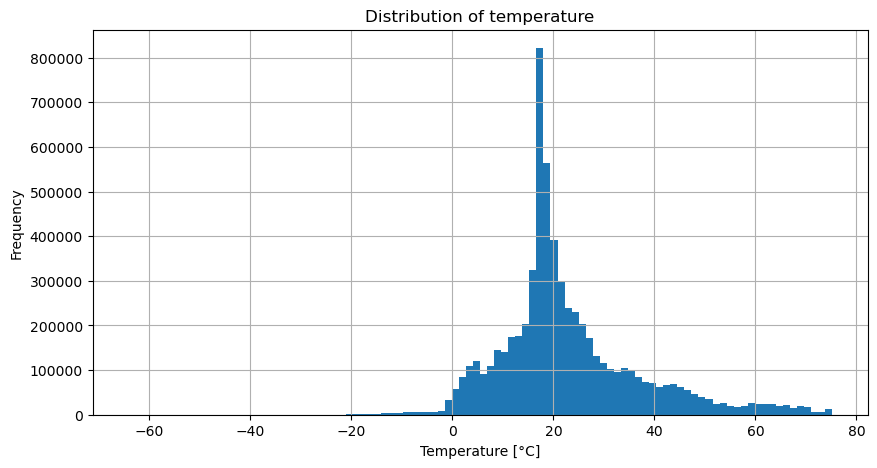

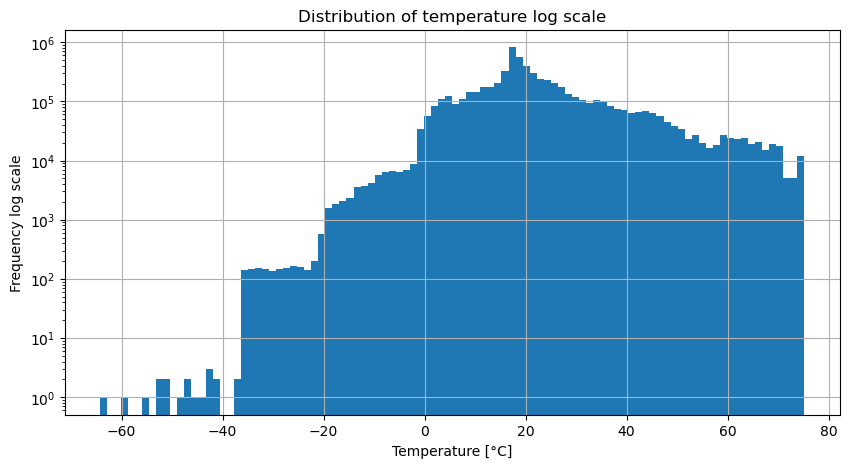

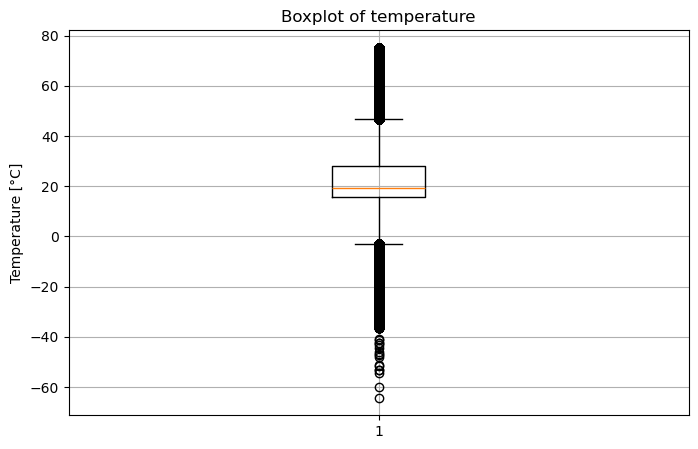

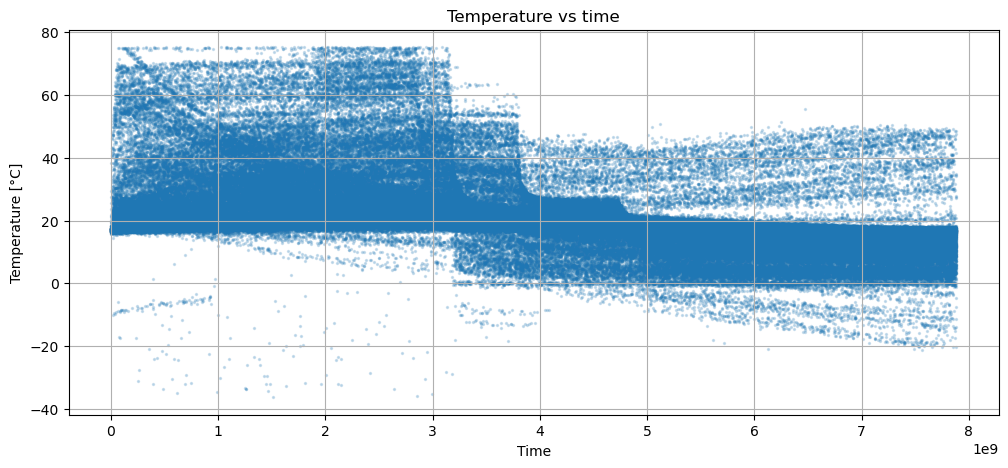

In [15]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

### 4.2 Feature Engineering

Features motivées par la physique du transfert thermique :
- **dist_canister** : la température décroît avec la distance au canister
- **is_opa** : zone OPA pondérée plus fortement dans le score Kaggle
- **time_log** : capture la dynamique exponentielle du transfert thermique
- **power_x_time, dist_x_time** : interactions physiques entre puissance, distance et temps
- **inv_dist_canister** : gradient radial près du canister
- **coor_x_squared** : non-linéarité spatiale en x
- **time_x_dist** : propagation du front thermique

In [ ]:
def add_features(df, sensors_df):
    """
    Add physics-motivated engineered features.
    Merges sensor coordinates if not already present (e.g. test set).

    Features:
    - coor_x, coor_y        : spatial position
    - dist_center           : distance from origin
    - dist_canister         : distance from canister center (x=0.7, y=1.2)
    - inv_dist_canister     : 1/dist (radial gradient)
    - dist_canister_sq      : dist² (radial non-linearity)
    - log_dist_canister     : log(1+dist) (logarithmic attenuation)
    - coor_x_squared        : spatial non-linearity in x
    - time_norm             : normalized time [0,1]
    - time_log              : log(1+t) (thermal diffusion dynamics)
    - cum_energy            : cumulative energy (thermal history)
    - power_over_dist2      : power / dist² (inverse square law)
    - power_x_inv_dist      : power × 1/dist (heat flux received)
    - energy_x_inv_dist     : cum_energy × 1/dist (total energy received)
    - power_x_time          : power × time (temporal interaction)
    - dist_x_log            : dist × log(time)
    """
    merged = df.copy()
    if 'coor_x' not in merged.columns:
        merged = merged.merge(sensors_df, on='sensor', how='left')

    t_max = t_max_ref

    # Spatial features
    merged['dist_center']       = np.sqrt(merged['coor_x']**2 + merged['coor_y']**2)
    merged['dist_canister']     = np.sqrt((merged['coor_x'] - 0.7)**2 + (merged['coor_y'] - 1.2)**2)
    merged['inv_dist_canister'] = 1 / (merged['dist_canister'] + 0.1)
    merged['dist_canister_sq']  = merged['dist_canister']**2
    merged['log_dist_canister'] = np.log1p(merged['dist_canister'])
    merged['coor_x_squared']    = merged['coor_x']**2

    # Temporal features
    merged['time_norm'] = merged['time'] / t_max
    merged['time_log']  = np.log1p(merged['time'])

    # Cumulative energy
    power_time = df[['time', 'power']].drop_duplicates('time').sort_values('time')
    power_time['dt']         = power_time['time'].diff().fillna(0)
    power_time['cum_energy'] = (power_time['power'] * power_time['dt']).cumsum()
    merged = merged.merge(
        power_time[['time', 'cum_energy']].drop_duplicates('time'),
        on='time', how='left'
    )

    # Physical interaction features
    merged['power_over_dist2']  = merged['power'] / (merged['dist_canister']**2 + 0.01)
    merged['power_x_inv_dist']  = merged['power'] * merged['inv_dist_canister']
    merged['energy_x_inv_dist'] = merged['cum_energy'] * merged['inv_dist_canister']
    merged['power_x_time']      = merged['power'] * merged['time_norm']
    merged['dist_x_log']        = merged['dist_canister'] * merged['time_log']

    return merged

train_feat = add_features(train_full, sensors)
test_feat  = add_features(test, sensors)
print('Features:', train_feat.columns.tolist())
display(train_feat.head(3))

Features: ['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z', 'dist_center', 'dist_canister', 'inv_dist_canister', 'dist_canister_sq', 'log_dist_canister', 'inv_sqrt_dist', 'coor_x_squared', 'time_norm', 'time_log', 'cum_energy', 'power_x_inv_dist', 'power_over_dist2', 'power_x_inv_sqrt_dist', 'energy_x_inv_dist', 'energy_x_inv_dist2', 'flux_x_logtime', 'power_x_time', 'dist_x_log']


,sensor,time,power,temperature,coor_x,coor_y,coor_z,dist_center,dist_canister,inv_dist_canister,...,time_log,cum_energy,power_x_inv_dist,power_over_dist2,power_x_inv_sqrt_dist,energy_x_inv_dist,energy_x_inv_dist2,flux_x_logtime,power_x_time,dist_x_log
0,N102,0.0,1487.964722,17.514429,46.131474,3.5,0.0,46.264053,45.489655,0.021935,...,0.000000,0.000000e+00,32.638210,0.719060,217.392441,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
1,N102,864000.0,1487.288818,17.820795,46.131474,3.5,0.0,46.264053,45.489655,0.021935,...,13.669329,1.285018e+09,32.623386,0.718734,217.293686,2.818660e+07,6.209858e+05,445.939808,0.162991,621.813063
2,N102,1728000.0,1486.612915,17.573187,46.131474,3.5,0.0,46.264053,45.489655,0.021935,...,14.362476,2.569451e+09,32.608559,0.718407,217.194946,5.636040e+07,1.241689e+06,468.339635,0.325833,653.344063


In [ ]:
TARGET   = 'temperature'
FEATURES = [
    'coor_x', 'coor_y',
    'power', 'cum_energy',
    'dist_center', 'dist_canister', 'inv_dist_canister',
    'dist_canister_sq', 'log_dist_canister',
    'coor_x_squared',
    'power_over_dist2', 'power_x_inv_dist',
    'energy_x_inv_dist',
    'power_x_time', 'dist_x_log',
]

X = train_feat[FEATURES].values
y = train_feat[TARGET].values

print(f'X shape : {X.shape} — {len(FEATURES)} features')

X shape : (6382332, 21) — 21 features


### 4.3 Split train/validation & Normalisation

In [20]:
# Split 80/20
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation : fit sur train uniquement pour éviter le data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(test_feat[FEATURES].values)

assert len(X_test_s) == len(test)
print(f'Train : {X_train_s.shape} | Val : {X_val_s.shape} | Test : {X_test_s.shape}')

Train : (5105865, 21) | Val : (1276467, 21) | Test : (2190480, 21)


## 5. Modèle — Random Forest

Extension des Decision Trees (lab svm_trees). Entraîne 100 arbres indépendants en parallèle
et moyenne leurs prédictions — robuste aux outliers, capture les interactions non-linéaires.

Hyperparamètres :
- `n_estimators=100` : 100 arbres
- `max_depth=15` : profondeur maximale
- `sample_size=1M500k` : sous-ensemble d'entraînement pour la rapidité

In [21]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
idx_rf = np.random.choice(len(X_train_s), size=350_000, replace=False)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,  # ← ajouter cette ligne
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_s[idx_rf], y_train[idx_rf])

y_pred_val_rf = rf.predict(X_val_s)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_val_rf))
print(f'Random Forest — RMSE validation : {rmse_rf:.4f}')

Random Forest — RMSE validation : 2.1877


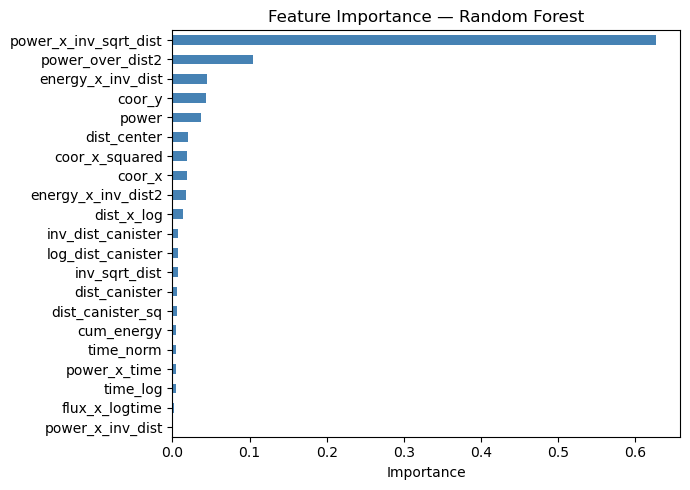

In [22]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(7, 5), color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Résultats — Random Forest

## 7. Prédictions finales & Soumission



In [23]:
y_pred = rf.predict(X_test_s)

submission = pd.DataFrame({
    'Id': np.arange(len(test), dtype=int),
    'temperature': y_pred.astype(float)
})

assert list(submission.columns) == ['Id', 'temperature']
assert len(submission) == len(test)
assert np.isfinite(submission['temperature']).all()
assert submission.isna().sum().sum() == 0

submission.to_csv('submission.csv', index=False)
print(f'Random Forest — RMSE validation : {rmse_rf:.4f}')
print(f'submission.csv sauvegardé — {len(submission)} lignes')
display(submission.head())

Random Forest — RMSE validation : 2.1877
submission.csv sauvegardé — 2190480 lignes


,Id,temperature
0,0,17.026819
1,1,17.026819
2,2,17.026819
3,3,17.034094
4,4,17.034094


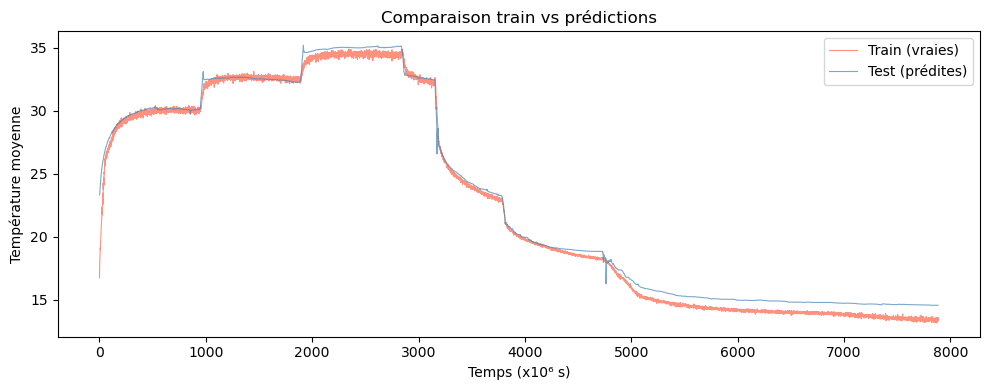

In [24]:
# Comparaison train vs prédictions par timestep
test_with_pred = test.copy()
test_with_pred['temperature_pred'] = y_pred

temp_train = train_full.groupby('time')['temperature'].mean()
temp_pred  = test_with_pred.groupby('time')['temperature_pred'].mean()

plt.figure(figsize=(10, 4))
plt.plot(temp_train.index / 1e6, temp_train.values,
         label='Train (vraies)', color='tomato', alpha=0.7, linewidth=0.8)
plt.plot(temp_pred.index / 1e6, temp_pred.values,
         label='Test (prédites)', color='steelblue', alpha=0.7, linewidth=0.8)
plt.title('Comparaison train vs prédictions')
plt.xlabel('Temps (x10⁶ s)')
plt.ylabel('Température moyenne')
plt.legend()
plt.tight_layout()
plt.show()

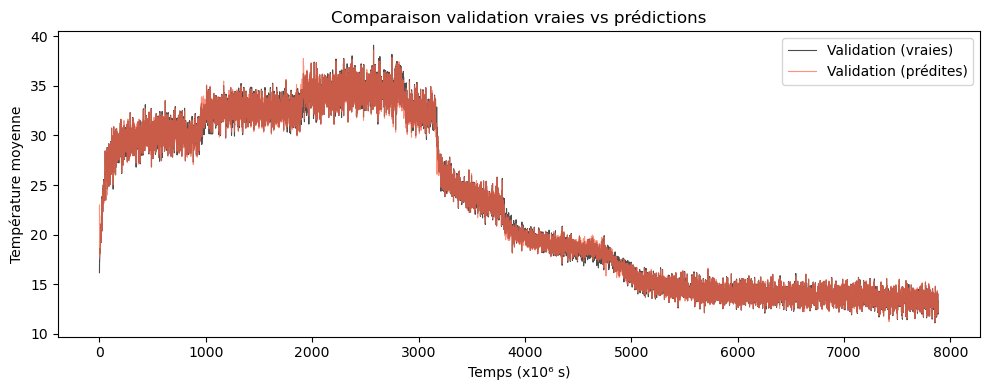

In [25]:
# comparaison validation vs prédictions 
from sklearn.model_selection import train_test_split

idx_all        = np.arange(len(train_feat))
idx_train, idx_val = train_test_split(idx_all, test_size=0.2, random_state=42)

val_with_pred  = train_feat.iloc[idx_val].copy()
val_with_pred['temperature_pred'] = y_pred_val_rf

temp_val_true = val_with_pred.groupby('time')['temperature'].mean()
temp_val_pred = val_with_pred.groupby('time')['temperature_pred'].mean()

plt.figure(figsize=(10, 4))
plt.plot(temp_val_true.index / 1e6, temp_val_true.values,
         label='Validation (vraies)', color='black', alpha=0.7, linewidth=0.8)
plt.plot(temp_val_pred.index / 1e6, temp_val_pred.values,
         label='Validation (prédites)', color='tomato', alpha=0.7, linewidth=0.8)
plt.title('Comparaison validation vraies vs prédictions')
plt.xlabel('Temps (x10⁶ s)')
plt.ylabel('Température moyenne')
plt.legend()
plt.tight_layout()
plt.show()

## Spatial Temparature Map: True vs Predicted

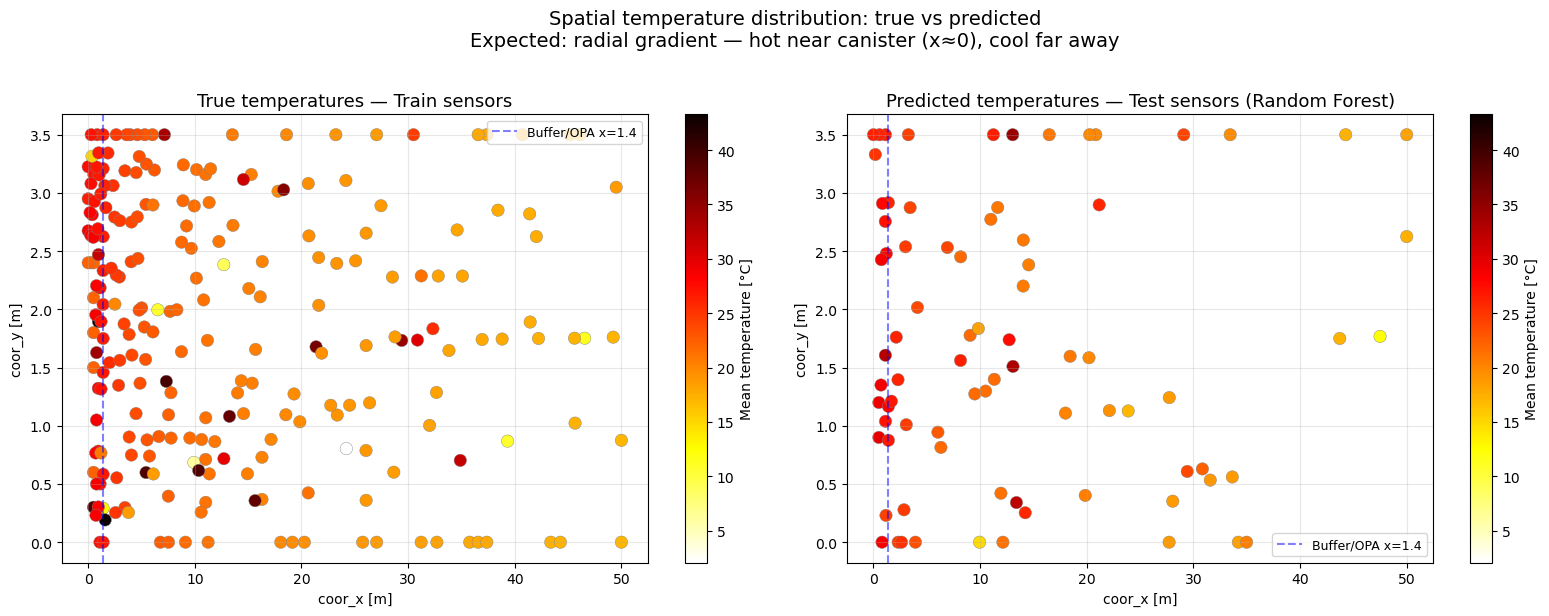

In [26]:
# Spatial temperature map: true vs predicted
# train_clean contient les vraies températures
# test_feat contient les coordonnées du test, y_pred les prédictions

train_sensor_temp = (
    train_full
    .groupby('sensor')
    .agg(coor_x=('coor_x', 'first'), coor_y=('coor_y', 'first'), mean_temp=('temperature', 'mean'))
    .reset_index())

test_feat['temp_pred'] = y_pred
test_sensor_temp = (
    test_feat
    .groupby('sensor')
    .agg(coor_x=('coor_x', 'first'), coor_y=('coor_y', 'first'), mean_temp=('temp_pred', 'mean'))
    .reset_index()
)

vmin = min(train_sensor_temp['mean_temp'].min(), test_sensor_temp['mean_temp'].min())
vmax = max(train_sensor_temp['mean_temp'].max(), test_sensor_temp['mean_temp'].max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(
    train_sensor_temp['coor_x'], train_sensor_temp['coor_y'],
    c=train_sensor_temp['mean_temp'], cmap='hot_r', vmin=vmin, vmax=vmax,
    s=80, edgecolors='gray', linewidths=0.3
)
axes[0].axvline(1.4, color='blue', linestyle='--', alpha=0.5, label='Buffer/OPA x=1.4')
axes[0].set_title('True temperatures — Train sensors', fontsize=13)
axes[0].set_xlabel('coor_x [m]'); axes[0].set_ylabel('coor_y [m]')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
plt.colorbar(sc1, ax=axes[0], label='Mean temperature [°C]')

sc2 = axes[1].scatter(
    test_sensor_temp['coor_x'], test_sensor_temp['coor_y'],
    c=test_sensor_temp['mean_temp'], cmap='hot_r', vmin=vmin, vmax=vmax,
    s=80, edgecolors='gray', linewidths=0.3
)
axes[1].axvline(1.4, color='blue', linestyle='--', alpha=0.5, label='Buffer/OPA x=1.4')
axes[1].set_title('Predicted temperatures — Test sensors (Random Forest)', fontsize=13)
axes[1].set_xlabel('coor_x [m]'); axes[1].set_ylabel('coor_y [m]')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.colorbar(sc2, ax=axes[1], label='Mean temperature [°C]')

plt.suptitle('Spatial temperature distribution: true vs predicted\n'
             'Expected: radial gradient — hot near canister (x≈0), cool far away',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Error Analysis By sensor

Worst sensors by RMSE:
             mae      rmse     coor_x    coor_y
sensor                                         
N818    2.591314  4.933901  10.359851  0.616177
N786    2.709381  4.909047   9.903648  0.685591
N550    2.445495  4.569626  13.246674  1.081154
N196    1.125630  4.421404   0.500000  0.300000
N918    2.708648  4.402223   0.358713  3.314945
N862    2.574087  4.384214   6.525898  1.996336
N589    2.534211  4.208033   7.327048  1.381086
N183    0.932783  3.962989   0.840000  3.500000
N350    1.953990  3.824898   2.499405  2.044796
N204    1.109457  3.823014   1.400000  0.291667


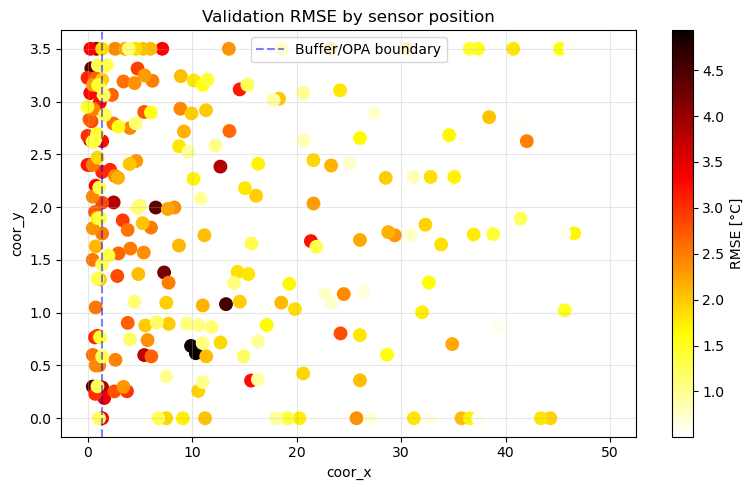

In [27]:
from sklearn.model_selection import train_test_split

# Recréer les mêmes indices que le split original
idx_all   = np.arange(len(train_feat))
idx_train, idx_val = train_test_split(idx_all, test_size=0.2, random_state=42)

val_results = train_feat.iloc[idx_val].copy().reset_index(drop=True)
val_results['y_true']    = y_val
val_results['y_pred']    = y_pred_val_rf
val_results['abs_error'] = np.abs(y_val - y_pred_val_rf)
val_results['sq_error']  = (y_val - y_pred_val_rf)**2

sensor_metrics = (
    val_results
    .groupby('sensor')
    .agg(
        mae   =('abs_error', 'mean'),
        rmse  =('sq_error',  lambda x: np.sqrt(np.mean(x))),
        coor_x=('coor_x', 'first'),
        coor_y=('coor_y', 'first'),
    )
    .sort_values('rmse', ascending=False)
)
print('Worst sensors by RMSE:')
print(sensor_metrics.head(10))

plt.figure(figsize=(8, 5))
sc = plt.scatter(
    sensor_metrics['coor_x'], sensor_metrics['coor_y'],
    c=sensor_metrics['rmse'], cmap='hot_r', s=80
)
plt.colorbar(sc, label='RMSE [°C]')
plt.axvline(1.4, color='blue', linestyle='--', alpha=0.5, label='Buffer/OPA boundary')
plt.xlabel('coor_x'); plt.ylabel('coor_y')
plt.title('Validation RMSE by sensor position')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()